<a href="https://colab.research.google.com/github/LongLongoooo/AIO_233/blob/AIO_Module_5/M05W01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!gdown 1OFgBOb4B1j32uK26vf5urkp8rqVmD_Wf
!unzip /content/titanic.zip

!gdown 1u_lWZPAVIdWG2gsi5myYhdtMoJ3MP0_j
!unzip /content/twitter_sentiment_analysis_2cls_dataset.zip

Downloading...
From: https://drive.google.com/uc?id=1OFgBOb4B1j32uK26vf5urkp8rqVmD_Wf
To: /content/titanic.zip
100% 7.00k/7.00k [00:00<00:00, 21.7MB/s]
Archive:  /content/titanic.zip
  inflating: titanic_modified_dataset.csv  
Downloading...
From: https://drive.google.com/uc?id=1u_lWZPAVIdWG2gsi5myYhdtMoJ3MP0_j
To: /content/twitter_sentiment_analysis_2cls_dataset.zip
100% 471k/471k [00:00<00:00, 83.2MB/s]
Archive:  /content/twitter_sentiment_analysis_2cls_dataset.zip
  inflating: sentiment_analysis.csv  


**Import Data**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ***Titanic Survive Prediction***

**Read Dataset**

In [4]:
dataset_path = "/content/titanic_modified_dataset.csv"
df = pd.read_csv(dataset_path, index_col = "PassengerId")


**X, y splitting**

In [5]:
dataset_arr = df.to_numpy().astype(np.float64)
X, y = dataset_arr[:, :-1], dataset_arr[:, -1]

# Add more bias b to X
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), axis=1)

# Train, val, test
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y,
    test_size = val_size,
    random_state= random_state,
    shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size= test_size,
    random_state= random_state,
    shuffle=is_shuffle
)


**Standardization of Data**

In [6]:
normalizer = StandardScaler()
# X_train/val/test = [1, a, b, c, ...] -> Normalization of X_train/val/test must be from the second element
# X_train use derivation and mean to transform so it needs fit_transform, therefore X_val and X_test just only need to
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])
X_train.shape


(623, 9)

**Set functions**

In [7]:
import numpy as np

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def predict(X, theta):
  z = np.dot(X, theta)
  y_hat = sigmoid(z)
  return y_hat

def loss(y_hat, y):
  y_hat = np.clip(y_hat, 0.0000001, 1 -  0.0000001)
  return (-y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)).mean()

def compute_gradient(X, y_hat, y):
  return np.dot(X.T, (y_hat - y)) / y.size

def update(theta, lr, gradient):
  return theta - lr * gradient

def compute_accuracy(X, y, theta):
  y_hat = predict(X, theta).round()
  return (y_hat == y).mean()


**Define global Variables**

In [8]:
lr = 0.01
epochs = 200
batch_size = 32
np.random.seed(random_state)
theta = np.random.uniform(size=X_train.shape[1])
theta

array([0.4359949 , 0.02592623, 0.54966248, 0.43532239, 0.4203678 ,
       0.33033482, 0.20464863, 0.61927097, 0.29965467])

**Train model**

In [9]:


# Initialize lists to hold metrics for each epoch
train_accs = []
train_losses = []
val_accs = []
val_losses = []

for epoch in range(epochs):
    train_batch_accs = []
    train_batch_losses = []
    val_batch_accs = []
    val_batch_losses = []

    for i in range(0, X_train.shape[0], batch_size):
      xi = X_train[i:i + batch_size]
      yi = y_train[i:i + batch_size]

      # Training part
      y_hat = predict(xi, theta)
      Loss = loss(y_hat, yi)
      gradient = compute_gradient(xi, y_hat, yi)
      theta = update(theta, lr, gradient)

      train_batch_losses.append(Loss)
      train_acc = compute_accuracy(xi, yi, theta)
      train_batch_accs.append(train_acc)

    # Validation part
    y_val_hat = predict(X_val, theta)
    loss_val = loss(y_val_hat, y_val)
    val_batch_losses.append(loss_val)
    acc_val = compute_accuracy(X_val, y_val, theta)
    val_batch_accs.append(acc_val)

    # Summarize batch results
    train_batch_loss = sum(train_batch_losses) / len(train_batch_losses)
    val_batch_loss = sum(val_batch_losses) / len(val_batch_losses)
    train_batch_acc = sum(train_batch_accs) / len(train_batch_accs)
    val_batch_acc = sum(val_batch_accs) / len(val_batch_accs)

    # Append epoch results
    train_losses.append(train_batch_loss)
    train_accs.append(train_batch_acc)
    val_losses.append(val_batch_loss)
    val_accs.append(val_batch_acc)

    # Print epoch summary
    print(f"\nEPOCH {epoch + 1}:\tTraining loss: {train_batch_loss:.3f}\tValidation loss: {val_batch_loss:.3f}")




EPOCH 1:	Training loss: 0.721	Validation loss: 0.599

EPOCH 2:	Training loss: 0.702	Validation loss: 0.589

EPOCH 3:	Training loss: 0.684	Validation loss: 0.580

EPOCH 4:	Training loss: 0.667	Validation loss: 0.572

EPOCH 5:	Training loss: 0.651	Validation loss: 0.565

EPOCH 6:	Training loss: 0.637	Validation loss: 0.558

EPOCH 7:	Training loss: 0.623	Validation loss: 0.552

EPOCH 8:	Training loss: 0.610	Validation loss: 0.547

EPOCH 9:	Training loss: 0.598	Validation loss: 0.542

EPOCH 10:	Training loss: 0.587	Validation loss: 0.537

EPOCH 11:	Training loss: 0.576	Validation loss: 0.533

EPOCH 12:	Training loss: 0.566	Validation loss: 0.529

EPOCH 13:	Training loss: 0.557	Validation loss: 0.525

EPOCH 14:	Training loss: 0.549	Validation loss: 0.522

EPOCH 15:	Training loss: 0.541	Validation loss: 0.520

EPOCH 16:	Training loss: 0.533	Validation loss: 0.517

EPOCH 17:	Training loss: 0.527	Validation loss: 0.515

EPOCH 18:	Training loss: 0.520	Validation loss: 0.513

EPOCH 19:	Training

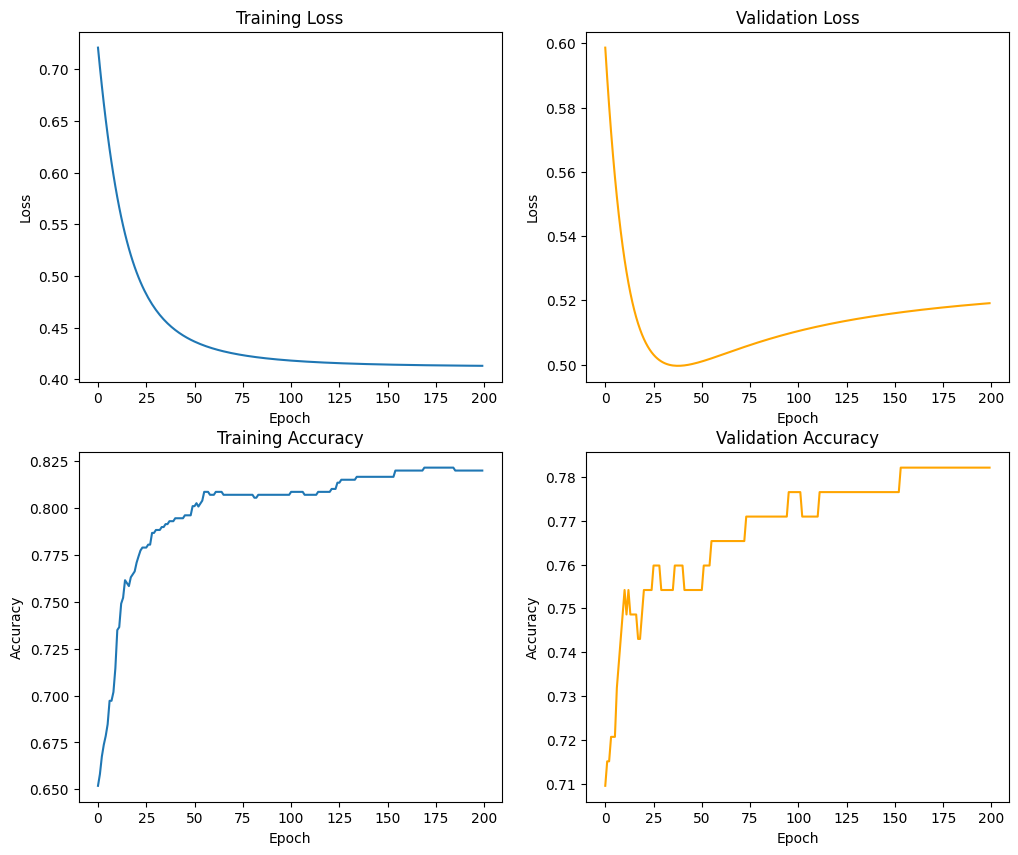

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Plot Training Loss
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

# Plot Validation Loss
ax[0, 1].plot(val_losses, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

# Plot Training Accuracy
ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

# Plot Validation Accuracy
ax[1, 1].plot(val_accs, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()


# **Twitter Sentiment Analysis**

In [11]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nltk.tokenize import TweetTokenizer
from collections import defaultdict


In [12]:
dframe =pd.read_csv("/content/sentiment_analysis.csv", index_col = "id")
dframe.head()

,label,tweet
id,,
1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
2,0,Finally a transparant silicon case ^^ Thanks t...
3,0,We love this! Would you go? #talk #makememorie...
4,0,I'm wired I know I'm George I was made that wa...
5,1,What amazing service! Apple won't even talk to...


In [13]:
dframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7920 entries, 1 to 7920
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   7920 non-null   int64 
 1   tweet   7920 non-null   object
dtypes: int64(1), object(1)
memory usage: 185.6+ KB


**Normalize text**

In [14]:
def text_normalize(text):
    # Retweet old acronym "RT" removal
    text = re.sub(r'^RT[\s]+', '', text)

    # Hyperlinks removal
    text = re.sub(r'https?://.*[\r\n]*', '', text)

    # Hashtags removal
    text = re.sub(r'#', '', text)

    # Punctuation removal
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenization
    tokenizer = TweetTokenizer(
        preserve_case=False,
        strip_handles=True,
        reduce_len=True
    )
    text_tokens = tokenizer.tokenize(text)

    return text_tokens

**Frequency storage of words**

In [15]:
def get_freqs(dframe):
  freqs = defaultdict(lambda:0)
  for indx, row in dframe.iterrows():
    tweet = row["tweet"]
    label = row["label"]

    tokens = text_normalize(tweet)
    for token in tokens:
      pair = (token, label)
      freqs[pair] += 1

  return freqs

**Get_features**

In [16]:
def get_feature(text, freqs):
  tokens = text_normalize(text)
  # (intercept, n_positives, n_negatives)
  X = np.zeros(3)
  X[0] = 1
  for token in tokens:
    X[1] += freqs[(token, 0)]
    X[2] += freqs[(token, 1)]

  return X

**Train, test split**

In [17]:
X = []
y = []

freqs = get_freqs(dframe)
for idx, row in dframe.iterrows():
  tweet = row["tweet"]
  label = row["label"]

  x_i = get_feature(tweet, freqs)
  X.append(x_i)
  y.append(label)

X = np.array(X)
y = np.array(y)

# Train, test split
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size = val_size,
    random_state=random_state,
    shuffle=is_shuffle)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=random_state,
    shuffle=is_shuffle
)

# Standardize data
standardizer = StandardScaler()
X_train[:, 1:] = standardizer.fit_transform(X_train[:,1:])
X_val[:, 1:] = standardizer.transform(X_val[:,1:])
X_test[:, 1:] = standardizer.transform(X_test[:,1:])


EPOCH 1:	Training loss: 0.760	Validation loss: 0.732	Training accuracy: 0.622	Validation accuracy: 0.646

EPOCH 2:	Training loss: 0.719	Validation loss: 0.693	Training accuracy: 0.639	Validation accuracy: 0.662

EPOCH 3:	Training loss: 0.682	Validation loss: 0.658	Training accuracy: 0.656	Validation accuracy: 0.677

EPOCH 4:	Training loss: 0.650	Validation loss: 0.628	Training accuracy: 0.676	Validation accuracy: 0.688

EPOCH 5:	Training loss: 0.621	Validation loss: 0.602	Training accuracy: 0.687	Validation accuracy: 0.700

EPOCH 6:	Training loss: 0.597	Validation loss: 0.580	Training accuracy: 0.697	Validation accuracy: 0.703

EPOCH 7:	Training loss: 0.576	Validation loss: 0.561	Training accuracy: 0.708	Validation accuracy: 0.715

EPOCH 8:	Training loss: 0.558	Validation loss: 0.544	Training accuracy: 0.716	Validation accuracy: 0.723

EPOCH 9:	Training loss: 0.542	Validation loss: 0.530	Training accuracy: 0.730	Validation accuracy: 0.740

EPOCH 10:	Training loss: 0.529	Validation los

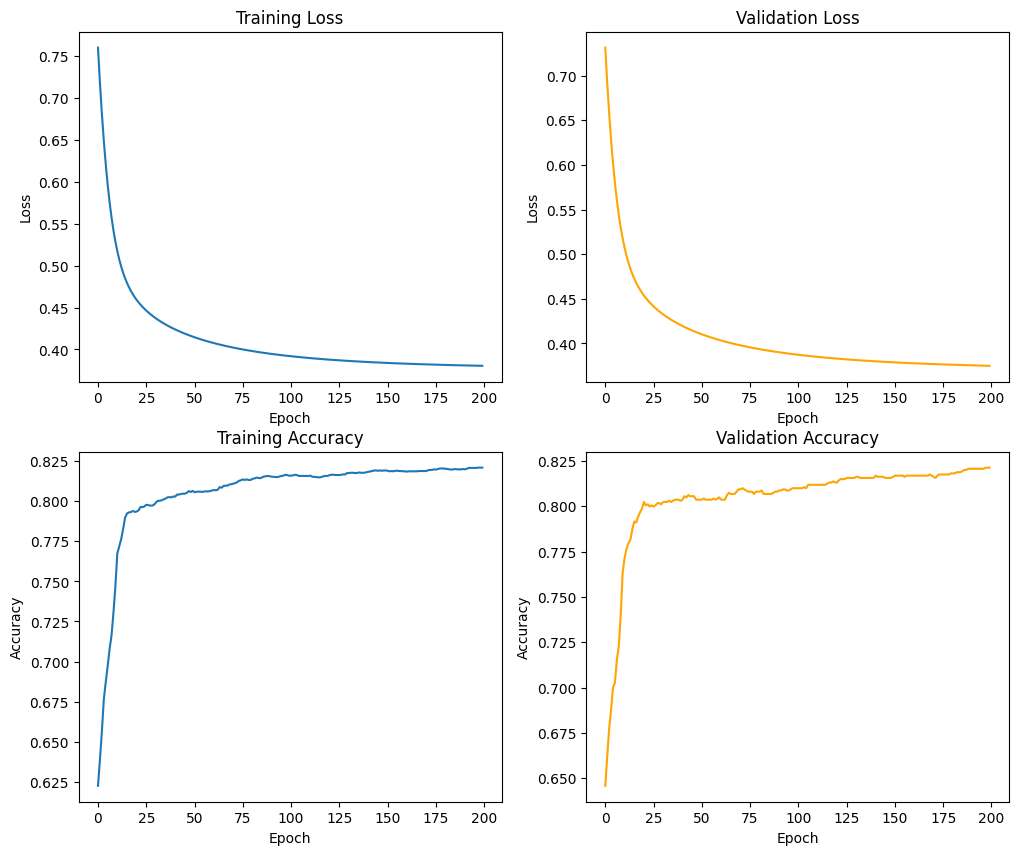

In [18]:
import numpy as np

def predict(X, theta):
    z = np.dot(X, theta)
    res = 1 / (1 + np.exp(-z))
    return res

def loss(y_hat, y):
    y_hat = np.clip(y_hat, 1e-7, 1 - 1e-7)
    return (-y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)).mean()

def compute_gradient(x, y_hat, y):
    return np.dot(x.T, (y_hat - y)) / y.size

def update_theta(theta, lr, gradient):
    return theta - lr * gradient

def compute_accuracy(X, y, theta):
    y_hat = predict(X, theta).round()
    acc = (y_hat == y).mean()
    return acc

# Define global variables
lr = 0.01
epochs = 200
batch_size = 128
random_state = 42
np.random.seed(random_state)
theta = np.random.uniform(size=X_train.shape[1])

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        xi = X_train[i: i + batch_size]
        yi = y_train[i: i + batch_size]

        # TRAIN PART
        y_hat = predict(xi, theta)
        batch_loss = loss(y_hat, yi)
        train_batch_losses.append(batch_loss)

        gradient = compute_gradient(xi, y_hat, yi)
        theta = update_theta(theta, lr, gradient)

        acc = compute_accuracy(xi, yi, theta)
        train_batch_accs.append(acc)

    # Validation Part
    y_hat_val = predict(X_val, theta)
    val_loss = loss(y_hat_val, y_val)
    val_acc = compute_accuracy(X_val, y_val, theta)

    # Summarize results for each epoch
    train_loss_epoch = sum(train_batch_losses) / len(train_batch_losses)
    train_acc_epoch = sum(train_batch_accs) / len(train_batch_accs)

    # Append epoch results
    train_losses.append(train_loss_epoch)
    train_accs.append(train_acc_epoch)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print epoch summary
    print(f"\nEPOCH {epoch + 1}:\tTraining loss: {train_loss_epoch:.3f}\tValidation loss: {val_loss:.3f}\tTraining accuracy: {train_acc_epoch:.3f}\tValidation accuracy: {val_acc:.3f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Plot Training Loss
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

# Plot Validation Loss
ax[0, 1].plot(val_losses, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

# Plot Training Accuracy
ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

# Plot Validation Accuracy
ax[1, 1].plot(val_accs, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()


In [22]:
X = np.array([[22.3, -1.5, 1.1, 1]])
theta = np.array([0.1, -0.15, 0.3, -0.2])
a = predict(X, theta)


loss(np.array([0.8, 0.75, 0.3, 0.95]), np.array([1, 0, 0, 1]))

0.5043515376900958

In [34]:
def compute_gradient (X, y_true , y_pred ):
  gradient = np. dot(X.T, ( y_pred - y_true )) / y_pred . size

  return gradient
X_t = np.array([[1, 3], [2, 1], [3, 2], [1, 2]])
y_true = np.array([1, 0, 1, 1])
y_pred = np.array( [0.7, 0.4, 0.6, 0.85])

compute_gradient(X_t, y_true, y_pred)

array([-0.2125, -0.4   ])

In [33]:
def compute_accuracy (y_true , y_pred ):
  y_pred_rounded = np. round ( y_pred )
  accuracy = np. mean ( y_true == y_pred_rounded )
  return accuracy
y_true = np.array([1, 0, 1, 1])
y_pred = np.array([0.85, 0.35, 0.9, 0.75])
compute_accuracy(y_true, y_pred)

1.0